## DATA ANALYSIS PYTHON PROJECT -BANK ANALYSIS

### **Import Libraries**

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### **Import Raw Data**

In [43]:
df=pd.read_csv(r"C:\Users\Asus\Downloads\Banking_messy_data.csv")

In [44]:
df.tail()

,CustomerID,Name,Age,Gender,City,AccountType,Bank,BranchManager,AccountOpenDate,TransactionDate,TransactionType,TransactionAmount,LoanAmount,CreditScore,LoanStatus
102495,CUST153459,Nikhil Malhotra,32.0,MALE,Jaipur,Salary,ICICI,Preeti Desai,26-08-2020,10-07-2022,Credit,"Rs. 17,376.61",NaN,781,NaN
102496,CUST110742,Gaurav Agarwal,42.0,Other,Hyderabad,Current,Axis Bank,Vikram Desai,22-02-2019,01-04-2020,Debit,"Rs. 31,213.10",500857.77,510,NaN
102497,CUST149689,Isha Gupta,28.0,Female,Bengalooru,Current,HDFC,NaN,22-09-2018,26-11-2020,Debit,"Rs. 19,077.67",NaN,625,NaN
102498,CUST158564,Anita Joshi,30.0,female,Kochi,Fixed Deposit,SBI,Rakesh Gupta,26-01-2019,29-01-2021,Debit,"Rs. 19,695.79",NaN,441,NaN
102499,CUST161615,Neha Verma,46.0,Female,jaipur,Current,Axis Bank,Pooja Agarwal,07-07-2018,21-07-2021,Debit,"Rs. 23,650.22",488808.64,733,Approved


###  **PHASE 1 — Data Understanding**


#### Check Data types and columns

In [45]:
print("--------------- Dataset Info -----------------")

# Show column names, data types, and how many non-missing values each column has
df.info()


--------------- Dataset Info -----------------
<class 'pandas.DataFrame'>
RangeIndex: 102500 entries, 0 to 102499
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         102500 non-null  str    
 1   Name               101395 non-null  str    
 2   Age                100493 non-null  float64
 3   Gender             101488 non-null  str    
 4   City               99435 non-null   str    
 5   AccountType        102500 non-null  str    
 6   Bank               102500 non-null  str    
 7   BranchManager      94249 non-null   str    
 8   AccountOpenDate    102500 non-null  str    
 9   TransactionDate    100416 non-null  str    
 10  TransactionType    102500 non-null  str    
 11  TransactionAmount  102500 non-null  str    
 12  LoanAmount         41140 non-null   float64
 13  CreditScore        102500 non-null  int64  
 14  LoanStatus         24755 non-null   str    
dtypes: float64(2), 

####  statistics Summary

In [46]:
print("----------- Summary statistics -------------")
df.describe()

----------- Summary statistics -------------


,Age,LoanAmount,CreditScore
count,100493.000000,4.114000e+04,102500.000000
mean,46.959748,1.024070e+06,595.786361
std,29.819067,5.630103e+05,183.104798
min,-74.000000,5.001384e+04,-1.000000
25%,31.000000,5.352263e+05,445.000000
50%,46.000000,1.026069e+06,598.000000
75%,61.000000,1.509996e+06,752.000000
max,224.000000,1.999835e+06,950.000000


#### Missing values check

In [47]:
print("----------- Missing Values -------------")
df.isnull().sum().reset_index(name='No of missing value')

----------- Missing Values -------------


,index,No of missing value
0,CustomerID,0
1,Name,1105
2,Age,2007
3,Gender,1012
4,City,3065
5,AccountType,0
6,Bank,0
7,BranchManager,8251
8,AccountOpenDate,0
9,TransactionDate,2084


#### Duplicate rows check


In [48]:
print('Duplicate rows:', df.duplicated().sum())
print('Duplicate CustomerID:', df['CustomerID'].duplicated().sum())

Duplicate rows: 1500
Duplicate CustomerID: 2500


In [49]:
for col in ['Gender', 'City', 'AccountType', 'Bank', 'LoanStatus']:
    print(col, '->', df[col].dropna().unique())

Gender -> <StringArray>
['Female', 'male', 'F', 'Male', 'M', 'Other', 'female', 'O', 'MALE']
Length: 9, dtype: str
City -> <StringArray>
[    'kolkata',      'MUMBAI',    'Banglore',     'Jaiipur', 'Chandiigarh',
     'Kolkata',    'Kolkatta',     'Mumbaii',       'delhi',    'Chennaii',
   'Hyderabad',  'Chandigarh',      'Kochii',        'Pune',   'Bengaluru',
      'Mumbai',   'hyderabad',      'Jaipur',       'kochi',        'Puna',
  'Bengalooru',      'jaipur',       'Kochi',        'pune',     'Chennai',
     'chennai',      'mumbai',      'Delhii',   'bengaluru',       'Delhi']
Length: 30, dtype: str
AccountType -> <StringArray>
['Fixed Deposit',       'Savings',        'Salary',       'Current',
       'current',       'savings',        'salary', 'fixed deposit']
Length: 8, dtype: str
Bank -> <StringArray>
['HDFC', 'Kotak Mahindra', 'SBI', 'PNB', 'Bank of Baroda', 'ICICI',
 'Axis Bank']
Length: 7, dtype: str
LoanStatus -> <StringArray>
['Approved', 'Rejected', 'Pending']
Lengt

###  **PHASE 2 — Data Cleaning**


#### Standarizing gender column

In [50]:
df['Gender'] = df['Gender'].astype('string').str.strip().str.lower()

df['Gender'] = df['Gender'].replace({
    'm': 'Male',
    'male': 'Male',
    'f': 'Female',
    'female': 'Female',
    'o': 'Other',
    'other': 'Other'
})

print(df['Gender'].value_counts(dropna=False))  #3 value count did not count nan thats why we use dropna equal to false

Gender
Male      52300
Female    45018
Other      4170
<NA>       1012
Name: count, dtype: Int64


#### Standarizing City column

In [51]:
df['City'] = df['City'].str.strip().str.title()

df['City'] = df['City'].replace(
    {'Bengalooru':'Bengaluru','Banglore':'Bengaluru','Jaiipur':'Jaipur','Chennaii':'Chennai','Delhii':'Delhi',
    'Kochii':'Kochi','Mumbaii':'Mumbai','Chandiigarh':'Chandigarh'})

print(df['City'].value_counts(dropna=False))

City
Jaipur        10056
Chennai       10027
Bengaluru     10004
Hyderabad      9985
Mumbai         9917
Delhi          9830
Kochi          9823
Chandigarh     9788
Kolkata        6752
Pune           6560
Puna           3374
Kolkatta       3319
NaN            3065
Name: count, dtype: int64


#### cleaning Age column 


In [52]:
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df.loc[(df['Age'] < 0) | (df['Age'] > 100), 'Age'] = np.nan
df['Age'] = df['Age'].fillna(df['Age'].median())

####  clean Dates 


In [53]:
## Mixed date formats into proper datetime format

df['TransactionDate']= pd.to_datetime(df['TransactionDate'],format='mixed',errors='coerce')
df['AccountOpenDate']= pd.to_datetime(df['AccountOpenDate'],format='mixed',errors='coerce')


In [54]:
####  Fix Impossible transaction dates 
df.loc[
    (df['AccountOpenDate'] < df['TransactionDate'],'TransactionDate')
    ] = np.nan


In [55]:
df['TransactionDate'].unique()

<DatetimeArray>
[                'NaT', '2019-02-09 00:00:00', '2021-10-26 00:00:00',
 '2024-04-11 00:00:00', '2020-06-15 00:00:00', '2020-07-15 00:00:00',
 '2018-07-23 00:00:00', '2017-11-29 00:00:00', '2018-03-28 00:00:00',
 '2019-10-12 00:00:00',
 ...
 '2018-10-23 00:00:00', '2024-10-05 00:00:00', '2021-10-17 00:00:00',
 '2022-09-07 00:00:00', '2018-09-04 00:00:00', '2021-05-21 00:00:00',
 '2023-02-24 00:00:00', '2023-07-18 00:00:00', '2021-03-22 00:00:00',
 '2022-04-15 00:00:00']
Length: 1754, dtype: datetime64[us]

#### Clean TransactionAmount 


In [56]:
df['TransactionAmount'] = (
    df['TransactionAmount']
    .astype(str)
    .str.replace('Rs.', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
)

df['TransactionAmount'] = pd.to_numeric(
    df['TransactionAmount'],
    errors='coerce'
)
df['TransactionAmount'] = df['TransactionAmount'].abs()

upper = df['TransactionAmount'].quantile(0.99)
df['TransactionAmount'] = df['TransactionAmount'].clip(upper=upper)


####  Standardize AccountType


In [57]:
df['AccountType'].unique()

<StringArray>
['Fixed Deposit',       'Savings',        'Salary',       'Current',
       'current',       'savings',        'salary', 'fixed deposit']
Length: 8, dtype: str

In [58]:
df['AccountType'] = df['AccountType'].str.strip().str.title()

#### clean Name and BranchManager 


In [59]:
df['Name'] = df['Name'].str.strip().str.title()

In [60]:
df['Name'] = df['Name'].str.strip().str.title()

#### Clean Credit Score

In [61]:
df['CreditScore'] = pd.to_numeric(
    df['CreditScore'], errors='coerce'
)
df.loc[
    (df['CreditScore'] < 300) | (df['CreditScore'] > 900),
    'CreditScore'
] = np.nan

#### Delete Dupluicates Row

In [62]:
df = df.drop_duplicates()

## Check duplictaes ows
print('Duplictaes rows:', df.duplicated().sum())


Duplictaes rows: 0


In [63]:
duplicate_customers = df[
    df['CustomerID'].duplicated(keep=False)
].sort_values('CustomerID')
print(duplicate_customers)

       CustomerID            Name   Age  Gender       City    AccountType  \
39802  CUST100012     Arjun Patel  57.0  Female  Bengaluru  Fixed Deposit   
25173  CUST100012     Arjun Patel  57.0  Female  Bengaluru  Fixed Deposit   
37165  CUST100037      Karan Iyer  61.0    Male     Mumbai        Savings   
37209  CUST100037      Karan Iyer  61.0    Male     Mumbai        Savings   
63673  CUST100162  Harsh Malhotra  31.0    Male   Kolkatta         Salary   
...           ...             ...   ...     ...        ...            ...   
91807  CUST199891        Isha Rao  24.0    Male       Puna         Salary   
78726  CUST199893      Gaurav Rao  41.0    Male     Jaipur        Savings   
90820  CUST199893      Gaurav Rao  41.0    Male     Jaipur        Savings   
86840  CUST199988       Ritu Nair  22.0  Female    Chennai  Fixed Deposit   
12884  CUST199988       Ritu Nair  22.0  Female    Chennai  Fixed Deposit   

                 Bank  BranchManager AccountOpenDate TransactionDate  \
398

In [64]:
print('Shape:', df.shape)
print('\nMissing values:')
print(df.isnull().sum())
print('\nData types:')
print(df.dtypes)

Shape: (101000, 15)

Missing values:
CustomerID               0
Name                  1094
Age                      0
Gender                 998
City                  3031
AccountType              0
Bank                     0
BranchManager         8120
AccountOpenDate          0
TransactionDate      97250
TransactionType          0
TransactionAmount        0
LoanAmount           60481
CreditScore           2012
LoanStatus           76629
dtype: int64

Data types:
CustomerID                      str
Name                            str
Age                         float64
Gender                       string
City                            str
AccountType                     str
Bank                            str
BranchManager                   str
AccountOpenDate      datetime64[us]
TransactionDate      datetime64[us]
TransactionType                 str
TransactionAmount           float64
LoanAmount                  float64
CreditScore                 float64
LoanStatus                  

In [65]:
df.to_csv('Bank_Poject_Cleaned.csv',index=False)
print("Cleand File is Saved")

Cleand File is Saved


## PHASE 3 — Exploratory Data Analysis (EDA)


In [66]:
df= pd.read_csv("Bank_Poject_Cleaned.csv")
df.head()


,CustomerID,Name,Age,Gender,City,AccountType,Bank,BranchManager,AccountOpenDate,TransactionDate,TransactionType,TransactionAmount,LoanAmount,CreditScore,LoanStatus
0,CUST162586,Nikhil Malhotra,22.0,Female,Kolkata,Fixed Deposit,HDFC,Anita Patel,2019-05-20,NaN,Credit,9170.73,NaN,407.0,NaN
1,CUST187265,Rohan Joshi,70.0,Male,Mumbai,Savings,Kotak Mahindra,Vikram Verma,2022-02-17,NaN,Credit,8035.20,NaN,415.0,NaN
2,CUST111769,Simran Kapoor,44.0,Female,Bengaluru,Fixed Deposit,SBI,Sneha Kapoor,2019-03-18,NaN,Debit,35592.97,NaN,358.0,NaN
3,CUST184002,Divya Menon,34.0,Male,Jaipur,Salary,PNB,Pooja Iyer,2019-06-10,2019-02-09,Credit,6307.00,NaN,728.0,NaN
4,CUST139274,Rohan Rao,47.0,Female,Chandigarh,Current,Kotak Mahindra,Divya Chopra,2021-09-25,NaN,Debit,36491.89,1380432.32,861.0,Approved


In [67]:
## Q1. Age distribution kaisi hai?
df['Age'].describe().reset_index()


,index,Age
0,count,101000.000000
1,mean,45.923297
2,std,15.922228
3,min,18.000000
4,25%,33.000000
5,50%,46.000000
6,75%,59.000000
7,max,74.000000


In [68]:
## Q2. Sabse zyada accounts kis AccountType ke hain?
df['AccountType'].value_counts().reset_index()

,AccountType,count
0,Fixed Deposit,25383
1,Current,25345
2,Salary,25152
3,Savings,25120


In [69]:
## Q3. Har AccountType ka average TransactionAmount kya hai?
Avg_transaction_AccountType = df.groupby('AccountType')['TransactionAmount'].mean()
Avg_transaction_AccountType.reset_index()

,AccountType,TransactionAmount
0,Current,16227.519399
1,Fixed Deposit,16165.385161
2,Salary,16211.504559
3,Savings,16280.751156


In [70]:
## Q4. Top 5 cities by total TransactionAmount
city_TrnsactionAmount = df.groupby('City')['TransactionAmount'].sum().sort_values(ascending=False)
city_TrnsactionAmount.reset_index().head()

,City,TransactionAmount
0,Mumbai,1.628427e+08
1,Jaipur,1.603724e+08
2,Chennai,1.601112e+08
3,Hyderabad,1.600898e+08
4,Bengaluru,1.587315e+08


In [71]:
## Q5. LoanStatus ke hisaab se average LoanAmount
Loan_status = df.groupby('LoanStatus')['LoanAmount'].sum()
Loan_status.reset_index().head()


,LoanStatus,LoanAmount
0,Approved,8.455626e+09
1,Pending,8.128851e+09
2,Rejected,8.381013e+09


In [72]:
## Q6. Kaunsa Bank sabse zyada Approved loans de raha hai?
df[df['LoanStatus'] == 'Approved']['Bank'].value_counts()


Bank
Kotak Mahindra    1272
ICICI             1251
HDFC              1194
Bank of Baroda    1181
Axis Bank         1138
PNB               1130
SBI               1117
Name: count, dtype: int64

In [73]:
 ## Q7CreditScore vs LoanStatus pattern
print(df.groupby('LoanStatus')['CreditScore'].mean())

LoanStatus
Approved    598.805946
Pending     599.767185
Rejected    596.478114
Name: CreditScore, dtype: float64


## PHASE 4 — Visualization


#### 1. Account count by AccountType — Bar Chart


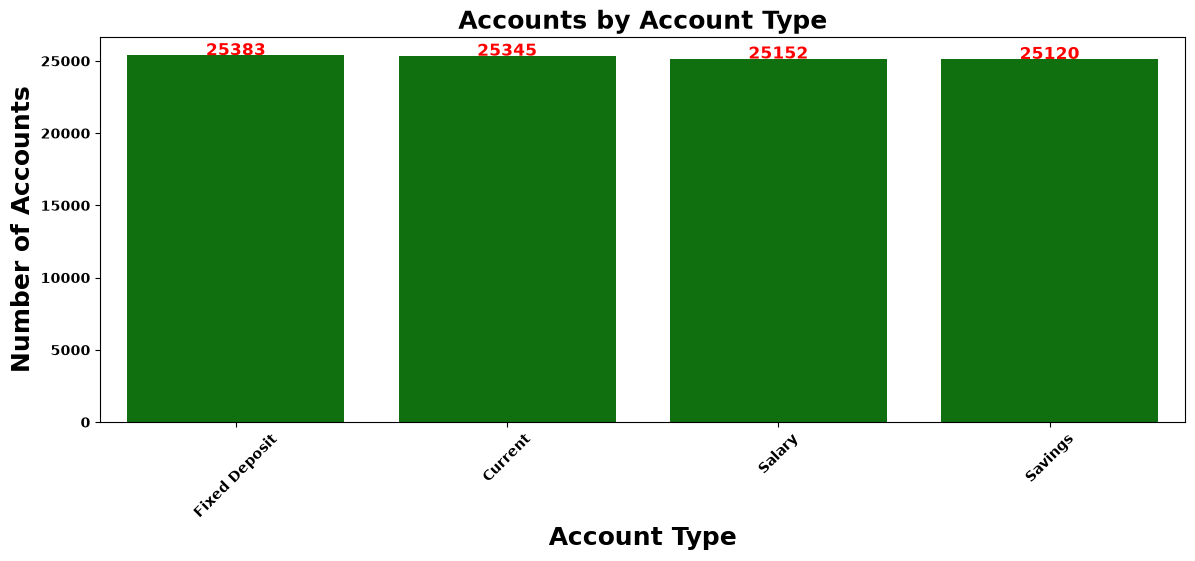

In [74]:
account_counts = df['AccountType'].value_counts()
plt.figure(figsize=(14,5))
sns.barplot(x=account_counts.index, y=account_counts.values,color='g')

for x,y in zip(account_counts.index,account_counts.values):
    plt.text(x,y+20,str(y),ha = 'center',fontsize=12,color='r',fontweight='bold')

plt.title('Accounts by Account Type',fontweight='bold', fontsize=18)
plt.xlabel('Account Type',fontweight='bold', fontsize=18)
plt.ylabel('Number of Accounts',fontweight='bold', fontsize=18)
plt.xticks(fontweight = 'bold', fontsize = 10, rotation = 45, ha = 'center')
plt.yticks(fontweight = 'bold', fontsize = 10)

plt.show()

#### 2. Monthly transaction trend — Line Chart


In [78]:
 df['TransactionDate'] =  pd.to_datetime(df['TransactionDate'])

In [79]:
df['MonthNmae'] = df['TransactionDate'].dt.month_name()

<function matplotlib.pyplot.show(close=None, block=None)>

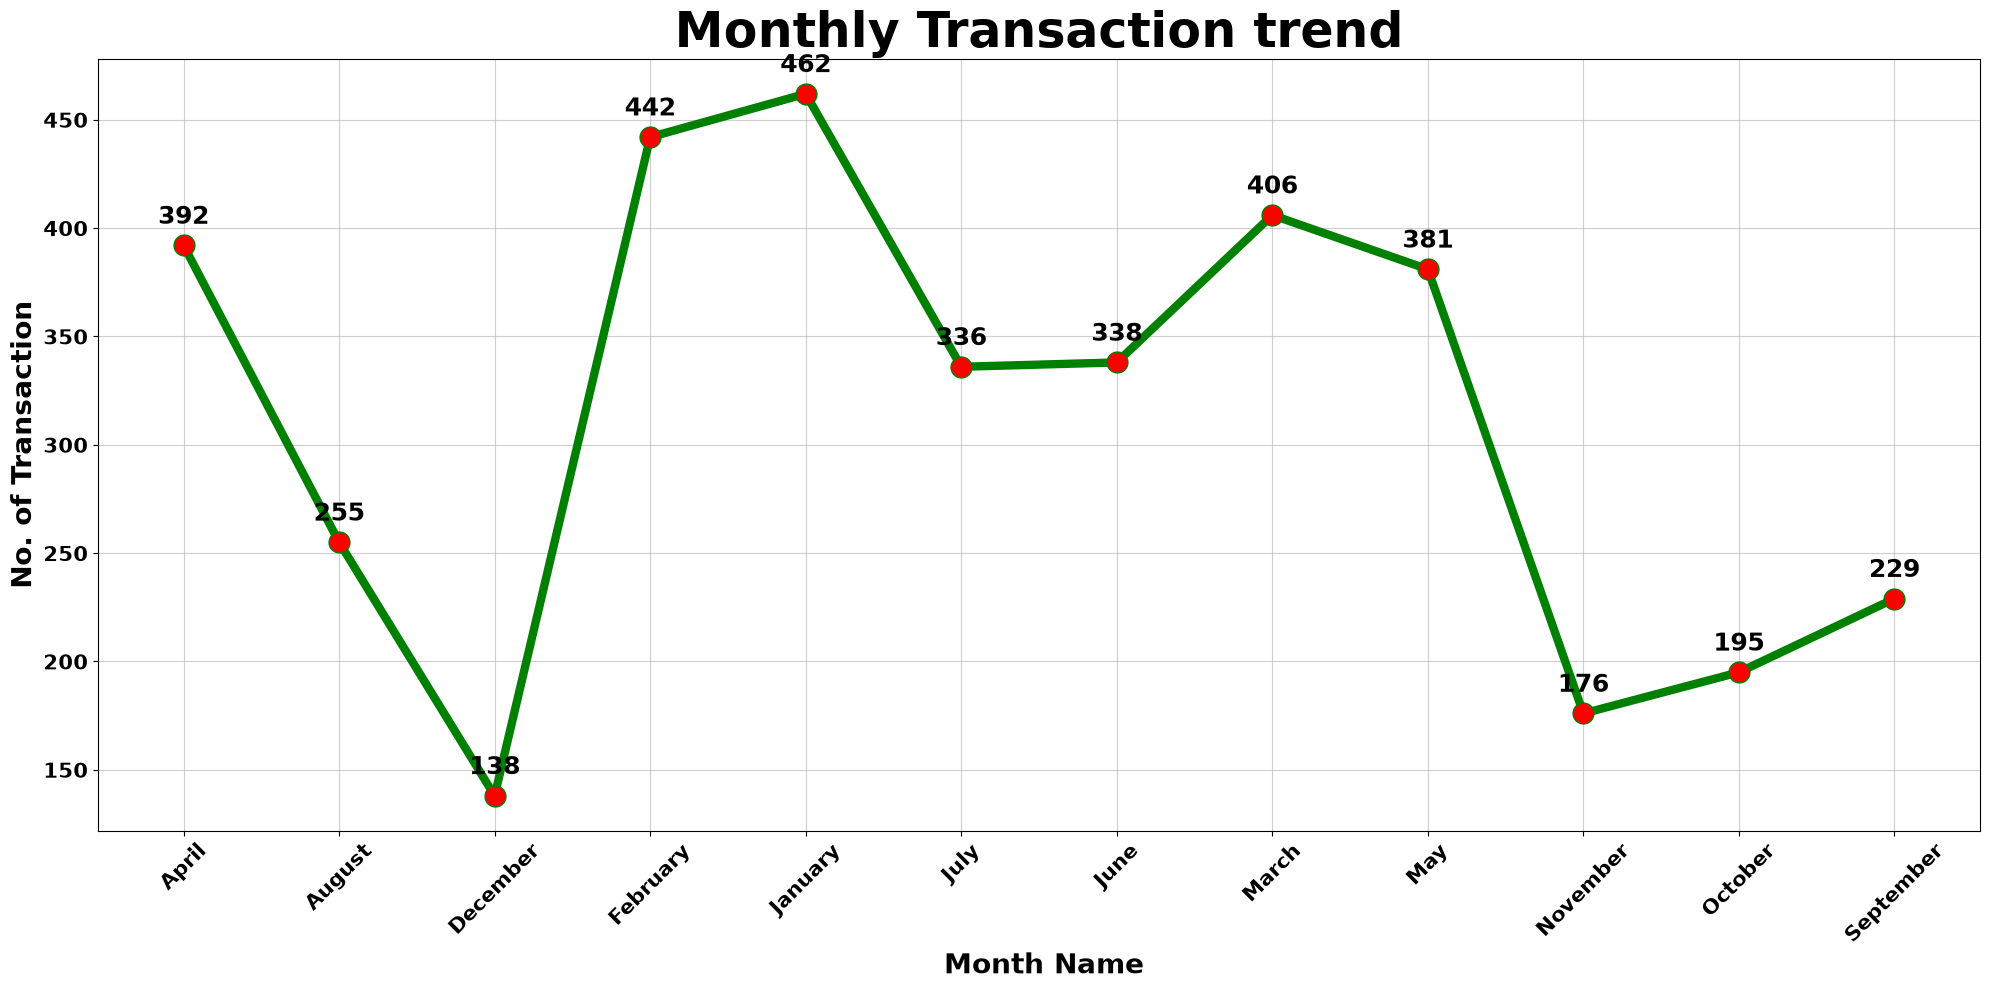

In [80]:
Monthly_transaction = df.groupby('MonthNmae')['TransactionDate'].count()

plt.figure(figsize=(20, 10))
plt.plot(Monthly_transaction.index, Monthly_transaction.values, linewidth= 6, marker= 'o', color ='g', 
markerfacecolor='r', markersize = 15)
plt.grid(True, alpha=0.6)

for x,y in zip (Monthly_transaction.index,Monthly_transaction.values):
    plt.text(x,y+10,f'{int(y):,}',ha = 'center',fontsize=18, fontweight = 'bold', color = 'k')
plt.title("Monthly Transaction trend", fontsize=35, fontweight = 'bold')
plt.xlabel(' Month Name', fontsize=20, fontweight = 'bold')
plt.ylabel('No. of Transaction', fontsize=20, fontweight = 'bold')
plt.xticks(fontweight = 'bold', fontsize = 15, rotation = 45, ha = 'center')
plt.yticks(fontweight = 'bold', fontsize = 15)
plt.tight_layout()
plt.show


#### 3. TransactionAmount by AccountType — Boxplot


In [ ]:
Account_Transaction_Amount = df.groupby('AccountType')['TransactionAmount'].sum()
Account_Transaction_Amount

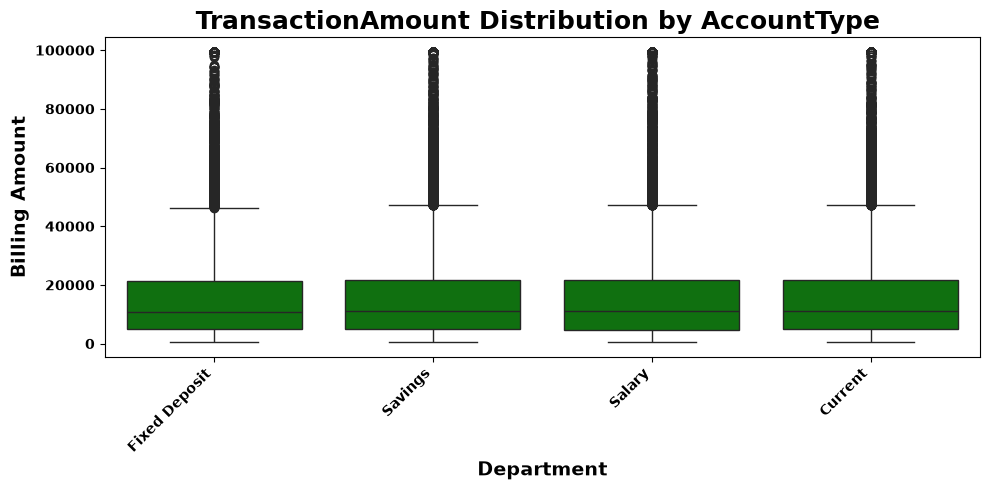

In [40]:
plt.figure(figsize=(10,5))
sns.boxplot(x='AccountType', y='TransactionAmount', data=df,color='green')
plt.title('TransactionAmount Distribution by AccountType ', fontsize=18, fontweight = 'bold')
plt.xlabel('Department', fontsize=14, fontweight = 'bold')
plt.ylabel('Billing Amount', fontsize=14, fontweight = 'bold')
plt.xticks(rotation=45, ha='right', fontsize=10, fontweight = 'bold')
plt.yticks(fontsize=10, fontweight = 'bold')

plt.tight_layout()

plt.show()


#### Correlation Heatmap

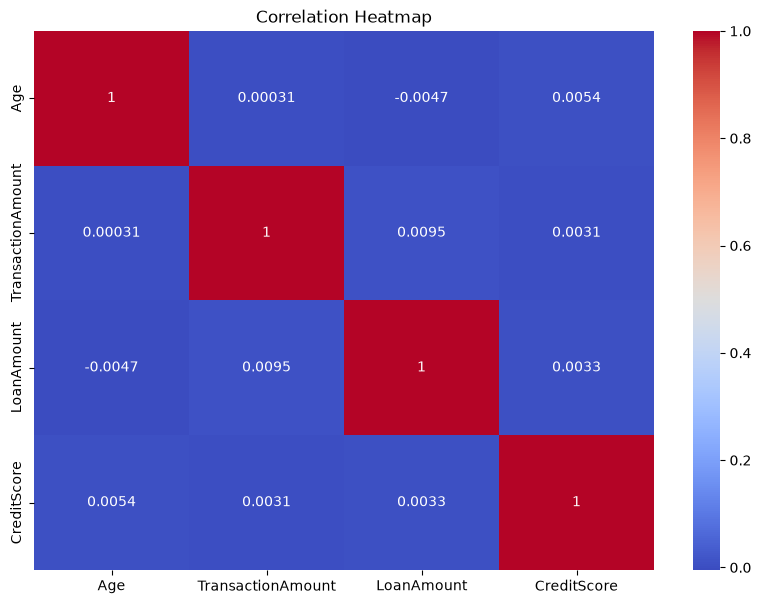

In [39]:
cols = ['Age', 'TransactionAmount', 'LoanAmount', 'CreditScore']
plt.figure(figsize=(10,7))
sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
df['LoanStatus'] = df['LoanStatus'].replace('NotFound','NotApproved')

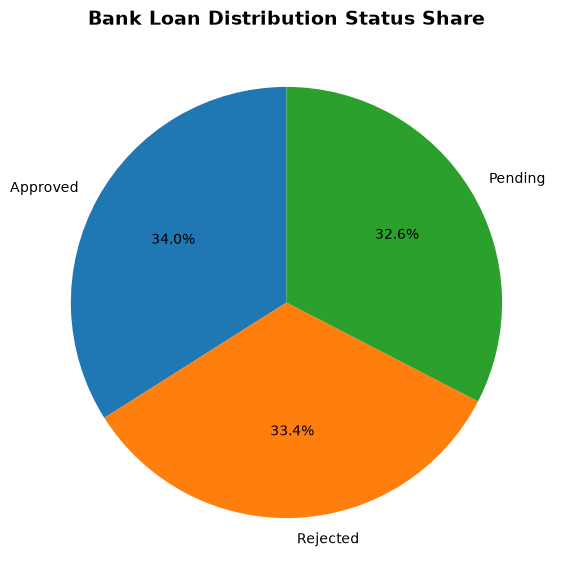

In [38]:
loan_share = df['LoanStatus'].value_counts()
plt.figure(figsize=(7,7))
plt.pie(loan_share.values, labels=loan_share.index, autopct='%1.1f%%',startangle=90)
plt.title('Bank Loan Distribution Status Share', fontsize=14, fontweight = 'bold')
plt.show()

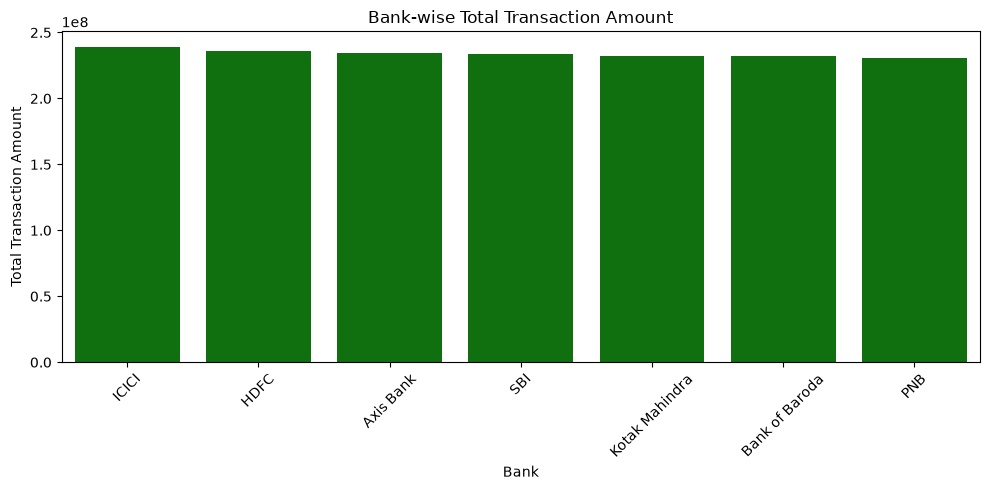

In [36]:
bank_total = (
    df.groupby('Bank')['TransactionAmount']
    .sum()
    .sort_values(ascending=False)
)
plt.figure(figsize=(10,5))
sns.barplot(x=bank_total.index, y=bank_total.values,color='g')
plt.title('Bank-wise Total Transaction Amount')
plt.xlabel('Bank')
plt.ylabel('Total Transaction Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

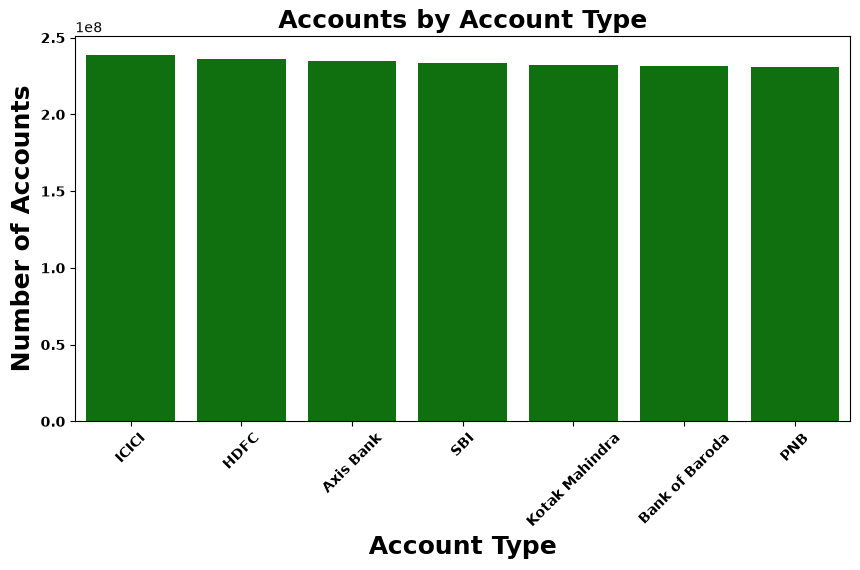

In [37]:
bank_total = (
    df.groupby('Bank')['TransactionAmount']
    .sum()
    .sort_values(ascending=False)
)
plt.figure(figsize=(10,5))
sns.barplot(x=bank_total.index, y=bank_total.values,color='g')


plt.title('Accounts by Account Type',fontweight='bold', fontsize=18)
plt.xlabel('Account Type',fontweight='bold', fontsize=18)
plt.ylabel('Number of Accounts',fontweight='bold', fontsize=18)
plt.xticks(fontweight = 'bold', fontsize = 10, rotation = 45, ha = 'center')
plt.yticks(fontweight = 'bold', fontsize = 10)

plt.show()